# 📊 Analyse Exploratoire des Données (EDA)
## Student Mental Health Prediction
### Objectif
L'objectif de cette phase est d'explorer le jeu de données afin de mieux comprendre sa structure, d'évaluer sa qualité, d'identifier les relations entre les variables et de dégager les premiers enseignements avant la phase de préparation des données et de modélisation.



In [1]:
#  Importation des bibliothèques
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
#importer la dataset
df = pd.read_csv("../dataset/student_depression_dataset.csv")

## 1. Analyse de la qualité des données
Objectif:
Évaluer la qualité du jeu de données avant toute analyse approfondie ou modélisation.
Cette étape permettra de vérifier :
- la présence de valeurs manquantes ;
- la présence de doublons ;
- la cohérence des types de données ;
- la cohérence des valeurs ;
- la présence éventuelle de valeurs aberrantes.

In [7]:
#identifions les variables contenant les valeurs manquantes
vals_manquantes=df.isnull().sum()
vals_manquantes


id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         0
Family History of Mental Illness         0
Depression                               0
dtype: int64

In [8]:
# Pourcentage de valeurs manquantes
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage

id                                       0.0
Gender                                   0.0
Age                                      0.0
City                                     0.0
Profession                               0.0
Academic Pressure                        0.0
Work Pressure                            0.0
CGPA                                     0.0
Study Satisfaction                       0.0
Job Satisfaction                         0.0
Sleep Duration                           0.0
Dietary Habits                           0.0
Degree                                   0.0
Have you ever had suicidal thoughts ?    0.0
Work/Study Hours                         0.0
Financial Stress                         0.0
Family History of Mental Illness         0.0
Depression                               0.0
dtype: float64

In [9]:
missing_data = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage (%)": round((df.isnull().sum()/len(df))*100,2)
})

missing_data.sort_values(by="Missing Values", ascending=False)

,Missing Values,Percentage (%)
id,0,0.0
Gender,0,0.0
Age,0,0.0
City,0,0.0
Profession,0,0.0
Academic Pressure,0,0.0
Work Pressure,0,0.0
CGPA,0,0.0
Study Satisfaction,0,0.0
Job Satisfaction,0,0.0


In [13]:
# Analyse des doublons
duplicates=df.duplicated().sum() #nbre de duplication
duplicates


np.int64(0)


Aucune observation dupliquée n'a été détectée dans le dataset.

In [14]:
#Comprendre la structure du dataset
df.shape

(27901, 18)

In [17]:
#séparation des variables catégorielles et numériques
categorical_columns = df.select_dtypes(include="object").columns.tolist()

numerical_columns = df.select_dtypes(include=["int64","float64"]).columns.tolist()

print("Variables catégorielles :", len(categorical_columns))
print(categorical_columns)

print()

print("Variables numériques :", len(numerical_columns))
print(numerical_columns)

Variables catégorielles : 9
['Gender', 'City', 'Profession', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Financial Stress', 'Family History of Mental Illness']

Variables numériques : 9
['id', 'Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours', 'Depression']


C:\Users\Hp\AppData\Local\Temp\ipykernel_15404\4253482298.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns.tolist()


##  Interprétation
Le dataset contient des variables numériques et des variables catégorielles.
Les variables numériques permettront d'étudier les distributions, les statistiques descriptives et les valeurs aberrantes.
Les variables catégorielles permettront d'analyser la répartition des différentes modalités et leur relation avec la variable cible.

#Analyse univariée
#Variable cible : Depression

#Objectif
L'objectif de cette première analyse est d'étudier la répartition de la variable cible **Depression**.

Cette étape permet de vérifier si les classes sont équilibrées ou déséquilibrées avant la phase de modélisation.

La compréhension de cette répartition est essentielle, car elle influence le choix des modèles de Machine Learning ainsi que les métriques d'évaluation.

In [19]:
#repartition de la variable cible
df["Depression"].value_counts()

Depression
1    16336
0    11565
Name: count, dtype: int64

In [21]:
#le pourcentage du depression
round(df["Depression"].value_counts(normalize=True) * 100, 2)

Depression
1    58.55
0    41.45
Name: proportion, dtype: float64

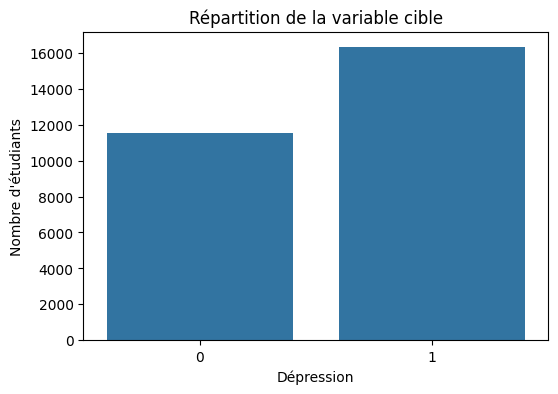

In [22]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Depression"
)

plt.title("Répartition de la variable cible")
plt.xlabel("Dépression")
plt.ylabel("Nombre d'étudiants")

plt.show()

In [23]:
# Analyse de la variable explicative : Gender
gender_counts = df["Gender"].value_counts()

gender_counts

Gender
Male      15547
Female    12354
Name: count, dtype: int64

In [24]:
round(df["Gender"].value_counts(normalize=True) * 100, 2)

Gender
Male      55.72
Female    44.28
Name: proportion, dtype: float64

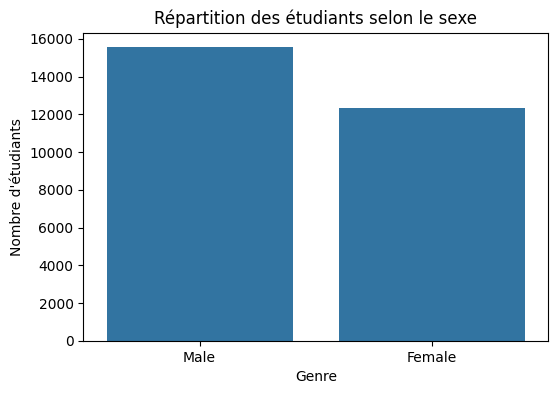

In [26]:
plt.figure(figsize=(6,4))

sns.countplot(data=df,x="Gender")

plt.title("Répartition des étudiants selon le sexe")
plt.xlabel("Genre")
plt.ylabel("Nombre d'étudiants")

plt.show()